In [36]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

import mlflow
import mlflow.pytorch

from product_tagger.config import MLFLOW_TRACKING_URI

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cuda


In [37]:
def get_model_from_mlflow(run_id: str, artifact_path: str = "model"):
    """
    Carga un modelo PyTorch desde un RUN de MLflow y lo deja en eval() y en el device.
    """
    mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
    model_uri = f"runs:/{run_id}/{artifact_path}"
    print("Loading model from:", model_uri)

    model = mlflow.pytorch.load_model(model_uri, map_location=device)
    model.to(device)
    model.eval()
    return model

In [38]:
def load_image_as_tensor(path, size=(224, 224)):
    """
    Devuelve:
        - tensor [1, 3, H, W] normalizado a [0,1]
        - imagen PIL redimensionada (para mostrar)
    """
    img = Image.open(path).convert("RGB")
    pil_img = img.resize(size)

    arr = np.array(pil_img).astype("float32") / 255.0  # [H, W, C] 0–1
    arr = np.transpose(arr, (2, 0, 1))                 # [C, H, W]
    tensor = torch.from_numpy(arr).unsqueeze(0)        # [1, C, H, W]
    return tensor, pil_img


In [39]:
def compute_cls_attention_map(attn_maps, layer_idx=-1, head_fusion="mean"):
    """
    Extrae la atención del token [CLS] hacia los demás tokens (patches)
    a partir de una lista de mapas de atención [B, H, T, T].

    attn_maps: lista de tensores [B, H, T, T]
    layer_idx: índice de la capa a usar (por defecto, -1 = última)
    head_fusion: 'mean' o 'max' para fusionar heads
    """
    attn = attn_maps[layer_idx]  # [B, H, T, T]
    attn = attn[0]               # batch 0 -> [H, T, T]

    if head_fusion == "mean":
        attn = attn.mean(dim=0)      # [T, T]
    elif head_fusion == "max":
        attn, _ = attn.max(dim=0)
    else:
        raise ValueError("head_fusion must be 'mean' or 'max'")

    cls_attn = attn[0]       # atención del token CLS
    cls_attn = cls_attn[1:]  # quitamos CLS→CLS, nos quedamos con CLS→patches

    return cls_attn  # vector 1D de tamaño num_patches


In [40]:
def cls_attention_to_map(cls_attn, img_size=(224, 224)):
    """
    Convierte el vector de atención (CLS→patches) en un mapa 2D del tamaño de la imagen.

    cls_attn: tensor 1D de tamaño num_patches
    img_size: (H, W) de la imagen final
    """
    num_patches = cls_attn.shape[0]
    grid = int(num_patches ** 0.5)  # asumimos grid cuadrado (ej: 14x14, 16x16, etc.)

    attn_map = cls_attn.reshape(1, 1, grid, grid)  # [1, 1, h, w]

    # Normalizar a [0,1]
    attn_map = attn_map - attn_map.min()
    if attn_map.max() > 0:
        attn_map = attn_map / attn_map.max()

    # Interpolar al tamaño de la imagen
    attn_map = F.interpolate(attn_map, size=img_size, mode="bilinear", align_corners=False)
    attn_map = attn_map.squeeze().numpy()  # [H, W]

    return attn_map


In [41]:
def show_attention_overlay(pil_img, attn_map, alpha=0.5, cmap="jet", title="Attention map"):
    """
    Superpone el mapa de atención (heatmap) sobre la imagen original.
    """
    plt.figure(figsize=(6, 6))
    plt.imshow(pil_img)
    plt.imshow(attn_map, cmap=cmap, alpha=alpha)
    plt.axis("off")
    plt.title(title)
    plt.show()


In [53]:
from pathlib import Path

IMAGES_DIR = Path(r"C:\importante\Master\VC3\TP-VPC3\data\processed\images\val")

VALID_EXT = {".jpg", ".jpeg", ".png"}

all_images = [p for p in IMAGES_DIR.iterdir() if p.suffix.lower() in VALID_EXT]

# Ordenar por el número del nombre de archivo (asumiendo nombres tipo '5000.jpg')
def numeric_key(path: Path):
    try:
        return int(path.stem)  # convierte '5000' -> 5000
    except ValueError:
        # Si hay archivos que NO son números puros, los mandamos al final
        return float("inf")

all_images_sorted = sorted(all_images, key=numeric_key)

# Ahora sí, las primeras 10 según número
image_paths = all_images_sorted[:10]

print("Encontradas:", len(all_images_sorted), "imágenes")
print("Usando estas 10 primeras (orden numérico por nombre):")
for p in image_paths:
    print(" -", p.name)


Encontradas: 6663 imágenes
Usando estas 10 primeras (orden numérico por nombre):
 - 1536.jpg
 - 1538.jpg
 - 1544.jpg
 - 1552.jpg
 - 1553.jpg
 - 1555.jpg
 - 1571.jpg
 - 1581.jpg
 - 1591.jpg
 - 1596.jpg


In [54]:
RUN_ID = "ad484a8bc4194f869d930c7f1706a398" #Write the run id you want
ARTIFACT_PATH = "model"
IMG_PATH = r"C:\importante\Master\VC3\TP-VPC3\data\processed\images\val\1536.jpg"

# 1) Cargar modelo
model = get_model_from_mlflow(RUN_ID, ARTIFACT_PATH)

# 2) Tomar el ÚLTIMO bloque del encoder (VisionTransformer de torchvision)
last_block = model.encoder.layers[-1]
print("Usando bloque:", last_block)

# Diccionario para guardar la entrada x a ese bloque
captured = {}

def enc_pre_hook(module, inputs):
    """
    Hook PRE-forward: guarda la entrada a last_block (x_block).
    inputs es una tupla; el primer elemento es x de ese bloque: [B, T, D]
    """
    x_block = inputs[0]
    captured["x_block"] = x_block.detach().to(device)

# Registrar hook PRE-forward solo en el último bloque
hook = last_block.register_forward_pre_hook(enc_pre_hook)

results = []  # guardará (pil_img, attn_map) para las 10 imágenes

for img_path in image_paths:
    print(f"\nProcesando: {img_path.name}")

    # Reset del diccionario capturado
    captured.clear()

    # --- 1) Cargar imagen ---
    x, pil_img = load_image_as_tensor(str(img_path))
    x = x.to(device)

    # --- 2) Forward del modelo (captura x_block en el hook) ---
    with torch.no_grad():
        _ = model(x)

    if "x_block" not in captured:
        raise RuntimeError("No se capturó x_block para esta imagen")

    x_block = captured["x_block"]  # [B, T, D]

    # --- 3) Calcular atención del último bloque ---
    y = last_block.ln_1(x_block)

    with torch.no_grad():
        attn_out, attn_weights = last_block.self_attention(
            y, y, y,
            need_weights=True,
            average_attn_weights=False,
        )

    # --- 4) CLS → patches → mapa ---
    attn_maps = [attn_weights.cpu()]
    cls_attn = compute_cls_attention_map(attn_maps, layer_idx=-1, head_fusion="mean")
    attn_map = cls_attention_to_map(cls_attn, img_size=pil_img.size[::-1])

    # Guardar para visualización posterior
    results.append((pil_img, attn_map))

# Quitar el hook
hook.remove()

print("¿Se capturó x_block?", "x_block" in captured)
if "x_block" in captured:
    print("x_block shape:", captured["x_block"].shape)
else:
    raise RuntimeError("No se capturó la entrada al último bloque (x_block).")


Loading model from: runs:/ad484a8bc4194f869d930c7f1706a398/model


Usando bloque: EncoderBlock(
  (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
  (self_attention): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
  )
  (dropout): Dropout(p=0.0, inplace=False)
  (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
  (mlp): MLPBlock(
    (0): Linear(in_features=768, out_features=3072, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.0, inplace=False)
    (3): Linear(in_features=3072, out_features=768, bias=True)
    (4): Dropout(p=0.0, inplace=False)
  )
)

Procesando: 1536.jpg

Procesando: 1538.jpg

Procesando: 1544.jpg

Procesando: 1552.jpg

Procesando: 1553.jpg

Procesando: 1555.jpg

Procesando: 1571.jpg

Procesando: 1581.jpg

Procesando: 1591.jpg

Procesando: 1596.jpg
¿Se capturó x_block? True
x_block shape: torch.Size([1, 197, 768])



Imagen 1/10


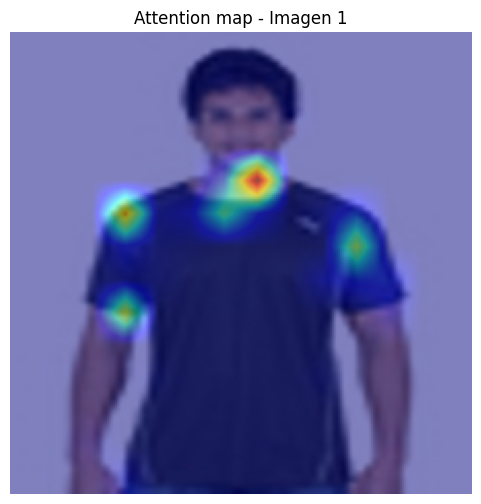


Imagen 2/10


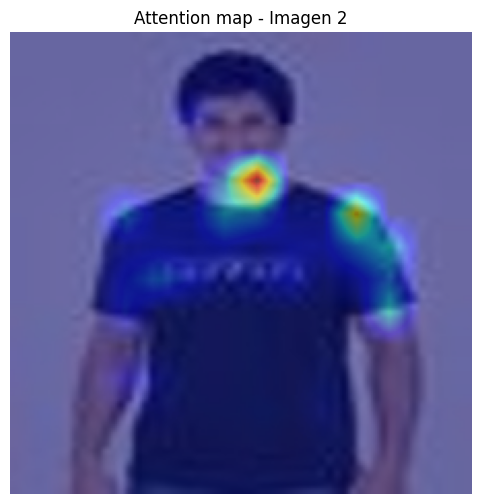


Imagen 3/10


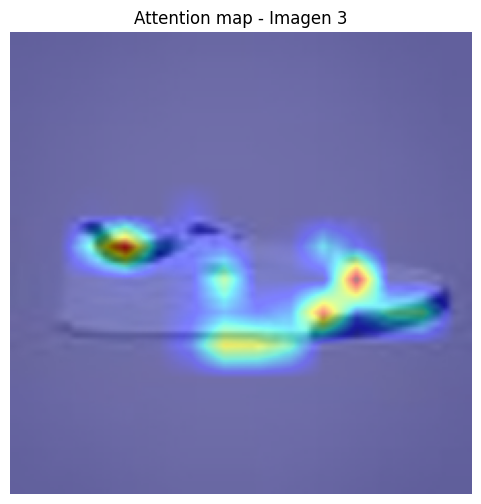


Imagen 4/10


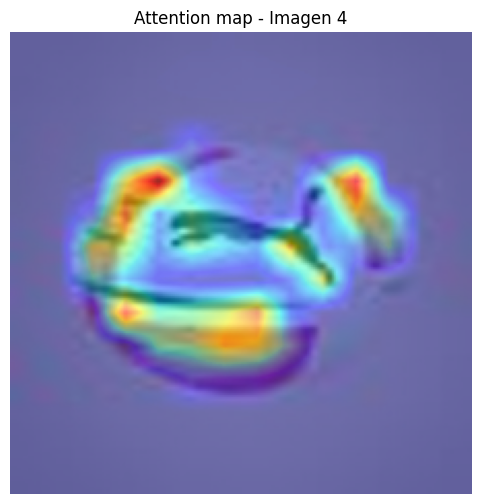


Imagen 5/10


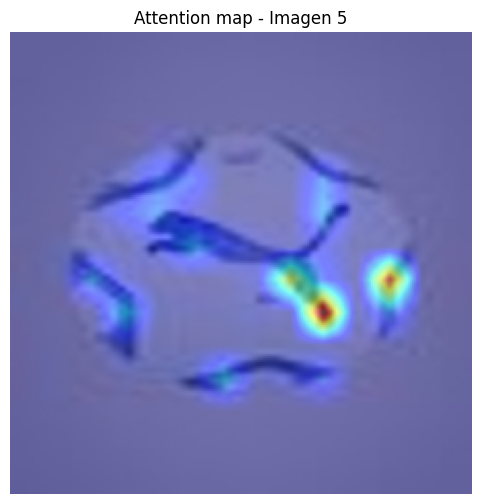


Imagen 6/10


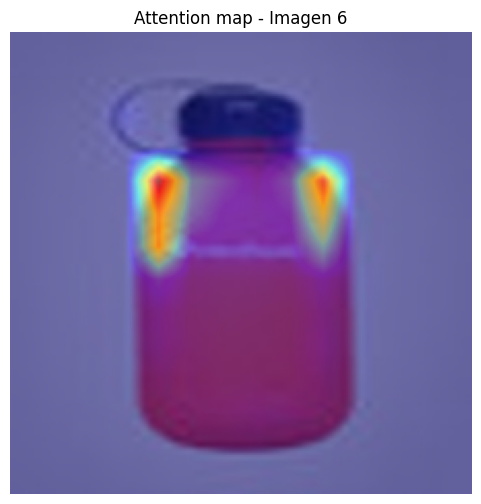


Imagen 7/10


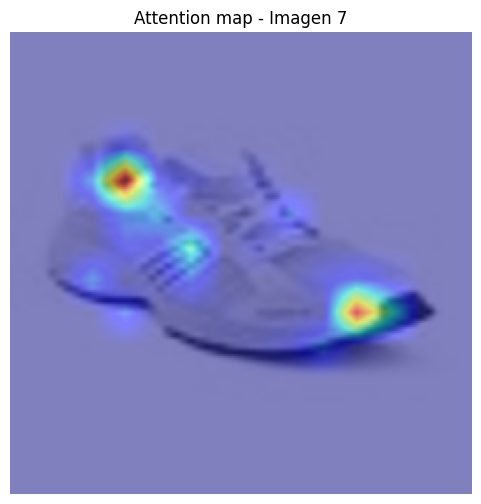


Imagen 8/10


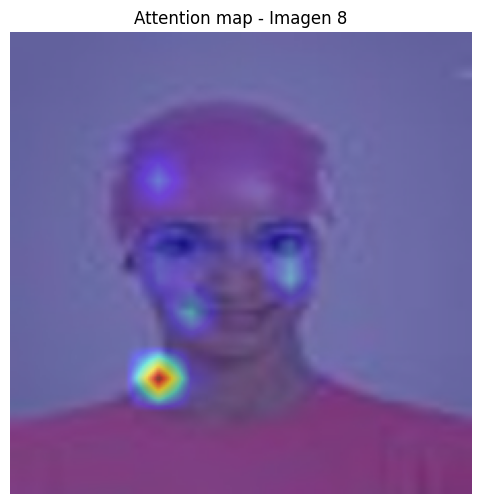


Imagen 9/10


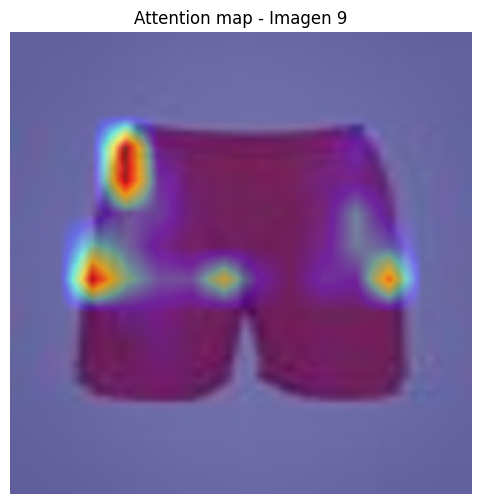


Imagen 10/10


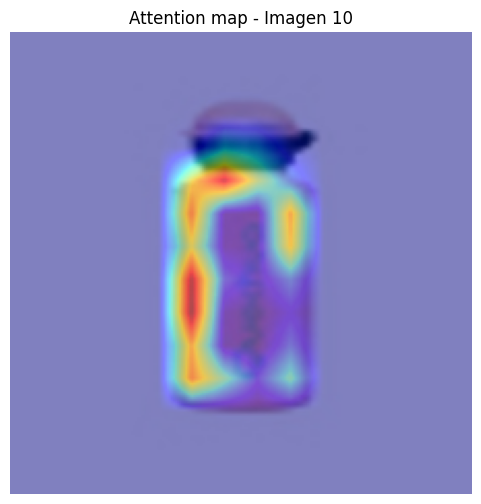

In [55]:
for idx, (pil_img, attn_map) in enumerate(results):
    print(f"\nImagen {idx+1}/{len(results)}")
    show_attention_overlay(pil_img, attn_map, alpha=0.5, cmap="jet",
                           title=f"Attention map - Imagen {idx+1}")
